# Analyze Lean Code Progress in `lean_type_sound`

This notebook parses the `.lean` files in `LeanTypeSound` to count the number of theorems, lemmas, and definitions, and checks how many are implemented (vs. left as `sorry`, which represents stubbed code generally produced initially or left unproven).

In [6]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## Configure Parsing Regex and Logic

We need to identify Lean blocks:
- `def ... :=`
- `theorem ... :=`
- `lemma ... :=`

And within each block, we check if the `sorry` block is present. If a block has `sorry`, it's an unproven stub. If not, it is fully implemented/proven.

In [7]:
# Regex patterns to locate declarations in Lean 4
# Matches lines starting with `theorem ` or `lemma `
declaration_pattern = re.compile(r'^\s*(theorem|lemma)\s+([a-zA-Z0-9_\']+)', re.MULTILINE)

# Target directory
target_dir = "LeanTypeSound"

def extract_blocks(content):
    """
    Extracts each declaration block from a Lean file string.
    A block starts from a match of declaration_pattern and runs up to the next match.
    """
    matches = list(declaration_pattern.finditer(content))
    blocks = []
    
    for i in range(len(matches)):
        start_idx = matches[i].start()
        end_idx = matches[i+1].start() if i + 1 < len(matches) else len(content)
        
        block = content[start_idx:end_idx]
        decl_type = matches[i].group(1)
        name = matches[i].group(2)
        
        blocks.append({
            'type': decl_type,
            'name': name,
            'content': block
        })
    return blocks

def is_proven(block):
    """
    A block is 'proven/implemented' if it does not contain 'sorry'.
    """
    if 'sorry' in block['content']:
        return False
    return True

## Scan and Parsen Lean Files 

Traverse all files under `LeanTypeSound` and analyze them.

In [8]:
results = []

print(f"Scanning target directory: {target_dir}")
for file_path in glob.glob(os.path.join(target_dir, "*.lean")):
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
    
    blocks = extract_blocks(content)
    
    for block in blocks:
        is_impl = is_proven(block)
        results.append({
            "File": os.path.basename(file_path),
            "Type": block['type'],
            "Name": block['name'],
            "Is_Proven": is_impl
        })

df = pd.DataFrame(results)
print(f"Total theorems found: {len(df)}")
df.head()

Scanning target directory: LeanTypeSound
Total theorems found: 269


,File,Type,Name,Is_Proven
0,Evaluate.lean,theorem,evaluate_clock,False
1,Evaluate.lean,theorem,fix_clock_evaluate,False
2,Evaluate.lean,theorem,fix_clock_do_eval_res,False
3,EvaluateProps.lean,theorem,io_events_mono_trans,False
4,EvaluateProps.lean,theorem,call_FFI_rel_io_events_mono,False


In [9]:
# List out all the theorems/lemmas that are still stubbed out with 'sorry'
unproven_theorems = df[df['Is_Proven'] == False]

print(f"Found {len(unproven_theorems)} unproven theorems:")
for _, row in unproven_theorems.iterrows():
    print(f" - {row['File']}: {row['Name']}")

Found 191 unproven theorems:
 - Evaluate.lean: evaluate_clock
 - Evaluate.lean: fix_clock_evaluate
 - Evaluate.lean: fix_clock_do_eval_res
 - EvaluateProps.lean: io_events_mono_trans
 - EvaluateProps.lean: call_FFI_rel_io_events_mono
 - EvaluateProps.lean: io_events_mono_refl
 - EvaluateProps.lean: do_app_call_FFI_rel
 - EvaluateProps.lean: do_app_io_events_mono
 - EvaluateProps.lean: is_clock_io_mono_cong
 - EvaluateProps.lean: is_clock_io_mono_return
 - EvaluateProps.lean: is_clock_io_mono_err
 - EvaluateProps.lean: is_clock_io_mono_bind
 - EvaluateProps.lean: is_clock_io_mono_check
 - EvaluateProps.lean: do_app_refs_length
 - EvaluateProps.lean: is_clock_io_mono_do_app_simple
 - EvaluateProps.lean: is_clock_io_mono_evaluate
 - EvaluateProps.lean: is_clock_io_mono_evaluate_decs
 - EvaluateProps.lean: is_clock_io_mono_extra
 - EvaluateProps.lean: evaluate_length
 - EvaluateProps.lean: is_clock_io_mono_set_clock
 - EvaluateProps.lean: is_clock_io_mono_minimal
 - EvaluateProps.lean: can

## Calculate and Display Percentages

Calculate ratio of Claude-proven constructs to total count, and visualize this in a plot mapping completion rate.

=== OVERALL PROGRESS ===
Total Constructs: 269
Proven/Implemented (Non-sorry): 78 (29.00%)
Unproven/Stubbed (Sorry): 191 (71.00%)

=== BREAKDOWN BY CONSTRUCT TYPE ===
Is_Proven  False  True 
Type                   
theorem      191     78


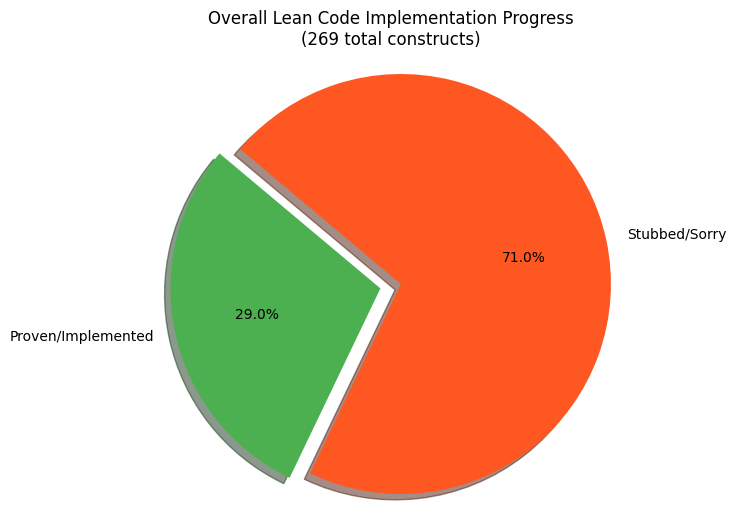

In [10]:
# Breakdown by Completion
summary_all = df['Is_Proven'].value_counts()
total_constructs = len(df)
proven_count = summary_all.get(True, 0)
unproven_count = summary_all.get(False, 0)

percentage_proven = (proven_count / total_constructs) * 100 if total_constructs > 0 else 0

print("=== OVERALL PROGRESS ===")
print(f"Total Constructs: {total_constructs}")
print(f"Proven/Implemented (Non-sorry): {proven_count} ({percentage_proven:.2f}%)")
print(f"Unproven/Stubbed (Sorry): {unproven_count} ({(100 - percentage_proven):.2f}%)\n")

# Breakdown by Type
breakdown_type = df.groupby(['Type', 'Is_Proven']).size().unstack(fill_value=0)
print("=== BREAKDOWN BY CONSTRUCT TYPE ===")
print(breakdown_type)

# Plot Overall Progress
plt.figure(figsize=(6, 6))
labels = ['Proven/Implemented', 'Stubbed/Sorry']
sizes = [proven_count, unproven_count]
colors = ['#4CAF50', '#FF5722']
explode = (0.1, 0)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title(f"Overall Lean Code Implementation Progress\n({total_constructs} total constructs)")
plt.axis('equal') 
plt.show()